# Fase 6 — Portfólio: juntar as quatro estratégias

**Objetivo.** A Fase 5 entregou quatro séries de retorno fora da amostra e já com custo. Aqui a pergunta é uma só: **juntar as quatro dá um resultado melhor do que ficar com a melhor delas?**

O caminho é ranquear, olhar a correlação (que é a única razão para combinar), testar três formas de alocar — pesos iguais, paridade de risco e Markowitz com teto —, ajustar o risco com vol targeting, decompor tudo em fatores e, no fim, refazer a conta com os pesos escolhidos sem olhar o resultado. A resposta curta está na seção 3 e não melhora até o fim.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import metrics, portfolio

plt.rcParams["figure.figsize"] = (10, 4)

R = pd.read_parquet(DATA / "processed" / "retornos_oos.parquet")   # Fase 5: fora da amostra, 10 bps
cdi = pd.read_parquet(DATA / "processed" / "cdi.parquet")["cdi"].reindex(R.index)
F = pd.read_parquet(DATA / "processed" / "fatores.parquet").reindex(R.index)   # NEFIN

print(R.shape, R.index.min().date(), "->", R.index.max().date())
print("CDI no período:", f"{metrics.annualized_return(cdi):.1%} ao ano")
R.head()

(2912, 4) 2015-01-02 -> 2026-09-14
CDI no período: 10.0% ao ano


,momentum,reversao,pares,carry
Date,,,,
2015-01-02,-0.001000,0.000435,0.000435,0.000694
2015-01-05,-0.011315,0.000435,0.000435,0.000959
2015-01-06,0.018740,0.000435,0.000435,0.001046
2015-01-07,0.028662,0.000435,0.000435,0.001309
2015-01-08,0.010103,0.022220,0.000435,0.000775


## 1. Ranqueamento — as quatro lado a lado

Antes de combinar, o retrato de cada uma. A régua é sempre a mesma das fases anteriores: Sharpe do excesso sobre o CDI. A última coluna é a correlação média de cada estratégia com as outras três — é ela que diz se há alguma coisa a ganhar juntando.

In [2]:
tabela = pd.DataFrame({c: metrics.summary(R[c], cdi) for c in R.columns}).T
corr = R.corr()
tabela["corr_media"] = (corr.sum(axis=1) - 1) / (len(corr) - 1)
tabela = tabela.sort_values("sharpe", ascending=False)
tabela.round(3)

,ret_anual,vol_anual,sharpe,max_dd,corr_media
momentum,0.166,0.266,0.354,-0.541,0.027
carry,0.099,0.010,-0.080,-0.025,0.023
pares,0.037,0.089,-0.616,-0.176,-0.031
reversao,-0.213,0.343,-0.790,-0.954,0.050


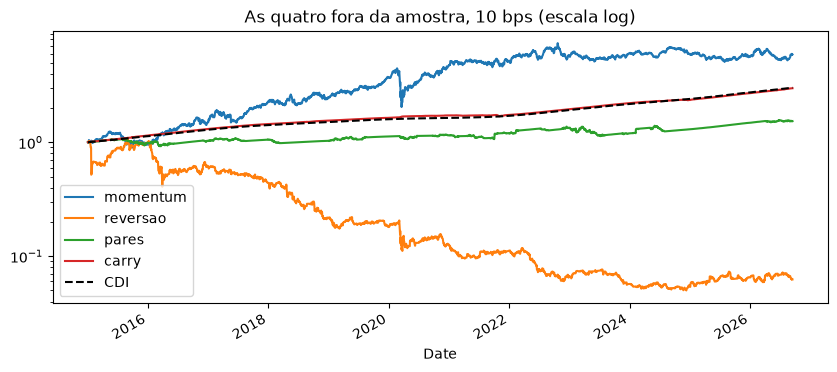

In [3]:
ax = (1 + R).cumprod().plot(logy=True, title="As quatro fora da amostra, 10 bps (escala log)")
(1 + cdi).cumprod().plot(ax=ax, color="black", ls="--", label="CDI")
ax.legend();

**A boa não é a diferente.** O ranking separa duas coisas que eu gostaria de ver na mesma linha e não estão:

- **A boa é o momentum:** Sharpe **+0,35**, o único acima do CDI (16,6% ao ano contra 10,0%). E é caro: vol de **26,6%** e drawdown de **−54%**.
- **A diferente é o par:** a única com correlação média **negativa** (−0,03) com as outras. Só que rende 3,7% ao ano — perde do CDI com Sharpe **−0,62**.
- **A mansa é o carry:** drawdown de **−2,5%** e vol de 1,0%, mas 9,9% ao ano, um triz abaixo do CDI (Sharpe −0,08). É quase uma posição em caixa com ruído.
- **A reversão perde em tudo:** −21,3% ao ano, drawdown de **−95%**, e ainda por cima é a de maior correlação média (+0,05). Não há ângulo pelo qual ela ajude.

Essa é a tensão desta fase inteira. Combinar só faz sentido quando o que é diferente também é bom; aqui o que é diferente é ruim, e o que é bom carrega quase todo o retorno. As seções seguintes são variações de como distribuir peso entre uma estratégia boa e três que perdem do CDI — e nenhuma regra de alocação conserta isso.

## 2. Correlação — a única razão para combinar

Se as quatro andassem juntas, juntar não reduziria risco nenhum. A correlação é, portanto, o número que autoriza ou desautoriza todo o resto do notebook. Olho quatro cortes dela: geral, só nos dias em que a estratégia está de fato posicionada, só nos dias de estresse, e ao longo do tempo.

In [4]:
corr.round(2)

,momentum,reversao,pares,carry
momentum,1.00,0.15,-0.10,0.03
reversao,0.15,1.00,-0.01,0.01
pares,-0.10,-0.01,1.00,0.02
carry,0.03,0.01,0.02,1.00


In [5]:
# o par fica fora do mercado boa parte do tempo; nesses dias o retorno dele é o CDI,
# e dia parado empurra qualquer correlação medida para perto de zero
ativo = (R["pares"] - cdi).abs() > 1e-10
print(f"dias com posição no par: {ativo.sum()} de {len(R)} ({ativo.mean():.0%})")
print("correlação pares × momentum, todos os dias:  ", round(R["pares"].corr(R["momentum"]), 2))
print("correlação pares × momentum, só dias ativos: ", round(R.loc[ativo, "pares"].corr(R.loc[ativo, "momentum"]), 2))

dias com posição no par: 1447 de 2912 (50%)
correlação pares × momentum, todos os dias:   -0.1
correlação pares × momentum, só dias ativos:  -0.13


In [6]:
# estresse = os 5% piores dias do mercado (fator MKT do NEFIN)
pior5 = F["MKT"] <= F["MKT"].quantile(0.05)
print("dias de estresse:", int(pior5.sum()))
R[pior5].corr().round(2)

dias de estresse: 143


,momentum,reversao,pares,carry
momentum,1.00,0.60,0.10,-0.04
reversao,0.60,1.00,0.05,-0.11
pares,0.10,0.05,1.00,0.12
carry,-0.04,-0.11,0.12,1.00


In [7]:
(R[pior5].corr() - corr).round(2)     # quanto cada correlação sobe quando o mercado cai

,momentum,reversao,pares,carry
momentum,0.00,0.45,0.20,-0.08
reversao,0.45,0.00,0.06,-0.13
pares,0.20,0.06,0.00,0.09
carry,-0.08,-0.13,0.09,0.00


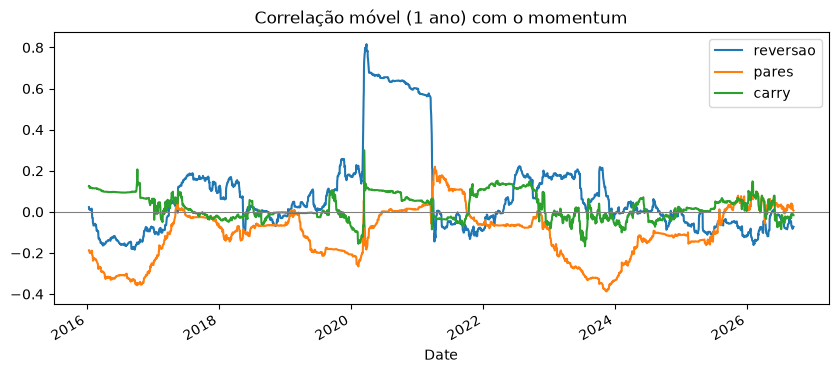

In [8]:
ax = R.drop(columns="momentum").rolling(252).corr(R["momentum"]).plot(
    title="Correlação móvel (1 ano) com o momentum")
ax.axhline(0, color="gray", lw=0.8);

**A diversificação some justamente no dia em que ela serviria.** No agregado o quadro é bom: a maior correlação em módulo é momentum × reversão, **+0,15**, e todo o resto fica abaixo de 0,10. Nos 5% piores dias do mercado (143 pregões) o quadro é outro:

| par | geral | estresse | variação |
|---|---|---|---|
| momentum × reversão | +0,15 | **+0,60** | +0,45 |
| momentum × pares | −0,10 | **+0,10** | +0,20 |
| pares × carry | +0,02 | +0,12 | +0,09 |
| reversão × carry | +0,01 | −0,11 | −0,13 |

As duas estratégias que carregam risco de verdade — momentum e reversão, 27% e 34% de vol — **quadruplicam** a correlação entre si quando o mercado despenca. Elas são independentes nos dias normais e passam a ser a mesma aposta no dia ruim. O par, que parecia o hedge por ser o único com correlação negativa, troca de sinal e também passa a andar junto.

O que continua descorrelacionado no estresse é o carry (−0,04 e −0,11 com momentum e reversão) — e vale lembrar de onde vem esse mérito: o carry é quase caixa. Ele não diversifica por ter um comportamento diferente, mas por quase não ter comportamento nenhum.

**Um aviso de medida, antes de acreditar em qualquer correlação daqui:** o par só tem posição em **1.447 dos 2.912 pregões** (50%) — no resto ele rende CDI. Dia parado é dia de retorno quase constante, e isso empurra qualquer correlação medida para perto de zero. Olhando só os dias ativos, a correlação dele com o momentum vai de −0,10 para −0,13. A diferença é pequena neste caso, mas a direção é a esperada: **a correlação da tabela geral está diluída por dias em que não há posição para correlacionar.**

A correlação móvel confirma que nada disso é estável: a relação momentum × reversão passeia de −0,2 a mais de +0,5 ao longo dos anos. **Qualquer alocação calculada com uma matriz de covariância fixa está usando um número que não fica parado.**

## 3. Pesos iguais vs melhor isolada — a tese em um número

A tese que motiva a fase é: quatro estratégias pouco correlacionadas juntas rendem parecido e oscilam menos. O teste mais simples dela é dividir o dinheiro em quatro partes iguais e comparar com ficar só na melhor.

In [9]:
w_ew = portfolio.equal_weight(R)
p_ew = portfolio.combine(R, w_ew)

print("Sharpe pesos iguais:", round(metrics.sharpe(p_ew, cdi), 2))
print("Melhor isolada:     ", round(tabela["sharpe"].max(), 2), f"({tabela['sharpe'].idxmax()})")

Sharpe pesos iguais: -0.5
Melhor isolada:      0.35 (momentum)


**−0,50 contra +0,35.** É a tese em um número, e ela não passa.

Dividir igualmente entre as quatro custou **0,85 de Sharpe** contra ficar só no momentum. A razão não tem nada de sutil: pesos iguais é a alocação que não olha para dado nenhum, então ela coloca 25% em cada uma das três estratégias que perdem do CDI. Diversificar só ajuda quando as coisas diversificadas têm retorno esperado parecido — aqui uma rende 16,6% ao ano e outra perde 21,3%.

Mas vale registrar o outro lado antes de seguir: a carteira de pesos iguais tem vol de **11,7%** contra 26,6% do momentum, e drawdown de **−27%** contra −54%. A combinação entregou metade do risco. O que ela não entregou foi retorno.

## 4. Paridade de risco — quem está realmente mandando na carteira

Peso em dinheiro não é peso em risco. Com vols tão diferentes (1% no carry, 34% na reversão), dividir o dinheiro em quatro partes iguais não divide o risco em quatro partes iguais. A conta que mostra isso é a contribuição de risco:

$$RC_i \;=\; w_i \cdot (\Sigma w)_i, \qquad \sum_i RC_i \;=\; \sigma_p^2$$

Cada estratégia contribui com o próprio peso vezes a covariância dela com a carteira inteira, e a soma fecha exatamente na variância — então `RC_i / ΣRC` é a **fração do risco** que cada uma ocupa.

In [10]:
vols = R.std(ddof=1) * np.sqrt(252)
vols.round(3)

momentum    0.266
reversao    0.343
pares       0.089
carry       0.010
dtype: float64

In [11]:
rc_ew = portfolio.risk_contribution(R, w_ew)
(rc_ew / rc_ew.sum()).round(2)              # fração do risco com pesos iguais

momentum    0.38
reversao    0.60
pares       0.02
carry       0.00
dtype: float64

In [12]:
w_rp = portfolio.risk_parity(R)             # pesos ∝ 1/vol
w_rp.round(3)

momentum    0.033
reversao    0.025
pares       0.098
carry       0.844
dtype: float64

In [13]:
rc_rp = portfolio.risk_contribution(R, w_rp)
(rc_rp / rc_rp.sum()).round(2)              # agora sim, perto de 25% para cada

momentum    0.26
reversao    0.27
pares       0.22
carry       0.25
dtype: float64

**Antes e depois, em fração do risco:**

| | momentum | reversão | pares | carry |
|---|---|---|---|---|
| **pesos iguais** (25% em cada) | 0,38 | **0,60** | 0,02 | 0,00 |
| **paridade de risco** | 0,26 | 0,27 | 0,22 | 0,25 |

Com 25% do dinheiro em cada, a reversão ocupava **60% do risco** e o carry, **0%**. A carteira de "pesos iguais" era, na prática, uma aposta na reversão — a pior das quatro. Depois do ajuste por 1/vol, cada uma fica entre 22% e 27%: a fração de risco vira de fato igual.

**O preço disso está nos pesos.** Igualar risco com vols tão díspares significa colocar **84,4% do dinheiro no carry** (vol de 1,0%) e **3,3% no momentum** (vol de 26,6%). A carteira de paridade de risco é uma posição em caixa com uma pitada de ações. Faz o que promete — vol de 1,8%, drawdown de −2,8% — mas rende 8,9% ao ano, abaixo do CDI.

Uma ressalva técnica: `risk_parity` aqui é 1/vol, que ignora correlações e só coincide com paridade de risco de verdade quando elas são baixas. A tabela acima mostra que, neste caso, coincide — as frações saíram perto de 0,25 justamente porque as correlações gerais são quase nulas. Em dias de estresse (seção 2) essa igualdade se desfaz.

## 5. Markowitz — o otimizador sem freio, e com freio

Pesos iguais não olha para nada; paridade de risco olha só para vol. Markowitz olha para tudo — médias, vols e correlações — e maximiza o Sharpe da carteira. É a alocação teoricamente correta e, na prática, a mais perigosa: ela trata a média histórica como se fosse retorno esperado.

In [14]:
from scipy.optimize import minimize

ex = R.sub(cdi, axis=0)
mu = ex.mean().to_numpy() * 252
cov_np = ex.cov().to_numpy() * 252
n = len(mu)

def neg_sharpe(w):
    var = w @ cov_np @ w
    return 0.0 if var <= 0 else -(w @ mu) / np.sqrt(var)

res = minimize(neg_sharpe, np.full(n, 1 / n), method="SLSQP",
               bounds=[(0, 1)] * n, constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])

print("médias de excesso, anualizadas:", (ex.mean() * 252).round(3).to_dict())
pd.Series(res.x, index=R.columns).round(3)       # a versão ingênua

médias de excesso, anualizadas: {'momentum': 0.094, 'reversao': -0.271, 'pares': -0.055, 'carry': -0.001}


momentum    1.0
reversao    0.0
pares       0.0
carry       0.0
dtype: float64

In [15]:
# portfolio.max_sharpe encolhe as médias para a média comum antes de otimizar:
#   mu <- (1 - shrink)·mu + shrink·média(mu)
for s in (0.0, 0.25, 0.5, 0.75, 1.0):
    print(f"shrink={s:<5}", portfolio.max_sharpe(R, cdi, w_max=0.4, shrink=s).round(2).to_dict())

shrink=0.0   {'momentum': 0.4, 'reversao': 0.0, 'pares': 0.2, 'carry': 0.4}
shrink=0.25  {'momentum': 0.4, 'reversao': 0.0, 'pares': 0.2, 'carry': 0.4}
shrink=0.5   {'momentum': 0.4, 'reversao': 0.0, 'pares': 0.2, 'carry': 0.4}
shrink=0.75  {'momentum': 0.4, 'reversao': 0.4, 'pares': 0.0, 'carry': 0.2}
shrink=1.0   {'momentum': 0.4, 'reversao': 0.4, 'pares': 0.0, 'carry': 0.2}


In [16]:
# e o teto de peso, que é o outro parâmetro que eu escolhi sem ter como calibrar
for wm in (0.25, 0.4, 0.6, 1.0):
    print(f"w_max={wm:<5}", portfolio.max_sharpe(R, cdi, w_max=wm, shrink=0.5).round(2).to_dict())

w_max=0.25  {'momentum': 0.25, 'reversao': 0.25, 'pares': 0.25, 'carry': 0.25}
w_max=0.4   {'momentum': 0.4, 'reversao': 0.0, 'pares': 0.2, 'carry': 0.4}
w_max=0.6   {'momentum': 0.6, 'reversao': 0.0, 'pares': 0.0, 'carry': 0.4}
w_max=1.0   {'momentum': 1.0, 'reversao': 0.0, 'pares': 0.0, 'carry': 0.0}


**Sem freio, o otimizador põe 100% no momentum.** Não é um bug — é o comportamento esperado de quem recebe as médias históricas como verdade: três das quatro têm média de excesso negativa (−27,1%, −5,5% e −0,1% ao ano), então a carteira de máximo Sharpe é ficar sozinho na única positiva. "Otimizar" aqui não diversificou nada; produziu a carteira de um ativo só.

Os dois freios contra isso são o encolhimento das médias e o teto de peso, e os dois têm o mesmo defeito:

- **O shrink não muda nada até que mude tudo.** De 0,0 a 0,5 os pesos são idênticos (0,4 / 0,0 / 0,2 / 0,4). Em 0,75 a reversão salta de **0 para 0,4** e o par vai de 0,2 para 0, porque encolher o suficiente faz a estratégia que perdeu 21% ao ano parecer tão boa quanto as outras. O resultado é descontínuo: nada, nada, e de repente 40% na pior série da amostra.
- **O teto é quem está realmente decidindo.** Com `w_max=1,0` sai 100% momentum; com `w_max=0,25` saem quatro pesos de 25%, que é exatamente a carteira de pesos iguais. Em todos os casos intermediários, pelo menos duas estratégias ficam **grudadas no teto**. Ou seja: os pesos não são a resposta do otimizador, são o número que eu digitei em `w_max`.

**Pesos que mudam muito com um parâmetro que eu não tenho como calibrar são pesos em que não se pode confiar.** Sigo com `w_max=0,4` e `shrink=0,5` no resto do notebook, mas sabendo que essa escolha é a alocação, e não o resultado de uma otimização.

## 6. As três combinações, medidas na mesma régua

Pesos iguais, paridade de risco e máximo Sharpe com teto, cada uma virando uma série de retorno, comparadas entre si e com a melhor estratégia isolada.

In [17]:
alocacoes = {
    "pesos_iguais": portfolio.equal_weight(R),
    "risk_parity":  portfolio.risk_parity(R),
    "max_sharpe":   portfolio.max_sharpe(R, cdi, w_max=0.4, shrink=0.5),
}
pd.DataFrame(alocacoes).round(3)

,pesos_iguais,risk_parity,max_sharpe
momentum,0.25,0.033,0.4
reversao,0.25,0.025,0.0
pares,0.25,0.098,0.2
carry,0.25,0.844,0.4


In [18]:
P = pd.DataFrame({nome: portfolio.combine(R, w) for nome, w in alocacoes.items()})

comparacao = pd.DataFrame({c: metrics.summary(P[c], cdi) for c in P.columns}).T
comparacao.loc["melhor_isolada"] = tabela.loc[tabela["sharpe"].idxmax(), comparacao.columns]
comparacao.round(3)

,ret_anual,vol_anual,sharpe,max_dd
pesos_iguais,0.031,0.117,-0.497,-0.267
risk_parity,0.089,0.018,-0.554,-0.028
max_sharpe,0.123,0.106,0.248,-0.249
melhor_isolada,0.166,0.266,0.354,-0.541


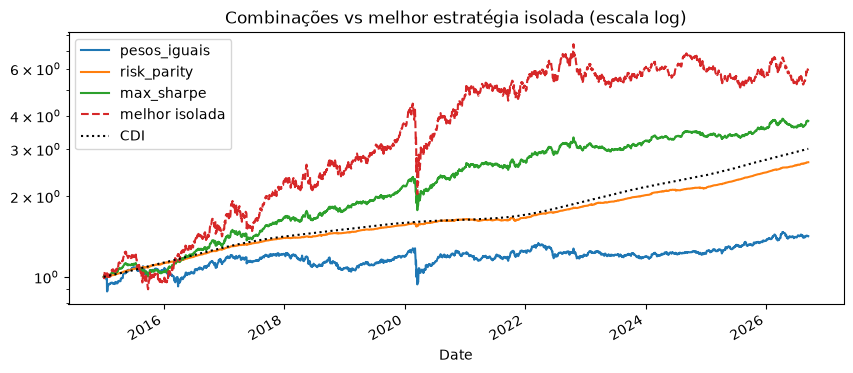

In [19]:
ax = (1 + P).cumprod().plot(logy=True, title="Combinações vs melhor estratégia isolada (escala log)")
(1 + R[tabela["sharpe"].idxmax()]).cumprod().plot(ax=ax, ls="--", label="melhor isolada")
(1 + cdi).cumprod().plot(ax=ax, color="black", ls=":", label="CDI")
ax.legend();

**Nenhuma das três bateu a melhor isolada.** O momentum sozinho fez Sharpe **0,35**; a melhor combinação, o `max_sharpe`, fez **0,25** — um terço a menos. Entre os três métodos a diferença é enorme (0,25 contra −0,50 dos pesos iguais e −0,55 da paridade de risco), e a razão é simples: o `max_sharpe` foi o único que pôde **zerar a reversão**, a estratégia que perdeu 21% ao ano e arrastou as outras duas alocações para baixo do CDI.

**O que a combinação comprou não foi retorno, foi risco.** O drawdown máximo caiu de **−54%** (momentum sozinho) para −25% no `max_sharpe` e **−2,8%** na paridade de risco; a vol anual saiu de 26,6% para 10,6% e **1,8%**. Se o critério fosse "quanto de perda eu aguento", e não Sharpe, a conclusão se inverteria — e a paridade de risco seria a resposta óbvia.

### A armadilha

O `max_sharpe` escolheu os pesos olhando **exatamente os mesmos retornos fora da amostra em que foi medido**. É overfitting de segunda ordem: a Fase 5 tirou o viés da escolha dos parâmetros de cada estratégia, e eu acabei de colocá-lo de volta na escolha dos pesos entre elas.

E não é um detalhe: ele é justamente **o único método aqui que ficou acima do CDI**. Pesos iguais e paridade de risco não têm esse problema (o primeiro não usa dado nenhum, o segundo só usa vols, que são muito mais estáveis que médias), e os dois terminaram com Sharpe negativo.

Ou seja: a única combinação que "funcionou" é a que espiou o gabarito. A seção 9 refaz essa conta escolhendo os pesos só com dados passados, e é lá que está o número em que eu acredito.

## 7. Vol targeting — mirar uma vol em vez de um peso

Alocação define quanto vai para cada estratégia; vol targeting define o tamanho da carteira inteira. A regra é escalar a posição todo dia pelo fator

$$k_t \;=\; \min\!\left(\frac{\sigma_{\text{alvo}}}{\hat\sigma_{t-1}},\; k_{\max}\right)$$

com a vol realizada estimada numa janela de 21 dias e **defasada um dia**, para não usar informação do próprio pregão. Aplico sobre a carteira de paridade de risco, que é a de menor vol — e é aí que a coisa fica interessante.

In [20]:
p = P["risk_parity"]
k = portfolio.vol_target_scale(p, target=0.10, window=21, max_leverage=2.0)

# versão ingênua: quando k < 1 a sobra rende CDI, mas quando k > 1 a alavancagem sai de graça
p_vt_free = k * p + (1 - k).clip(lower=0) * cdi

print(f"vol antes: {metrics.annualized_vol(p):.3f}   depois: {metrics.annualized_vol(p_vt_free):.3f}   (alvo: 0.100)")
print(f"k:  média {k.mean():.2f} | mediana {k.median():.2f} | mín {k.min():.2f} | máx {k.max():.2f}")
print(f"dias com k no teto de 2,0: {(k >= 1.999).mean():.1%}   |   dias com k < 1: {(k < 1).mean():.1%}")

vol antes: 0.018   depois: 0.034   (alvo: 0.100)
k:  média 1.99 | mediana 2.00 | mín 1.00 | máx 2.00
dias com k no teto de 2,0: 98.2%   |   dias com k < 1: 0.0%


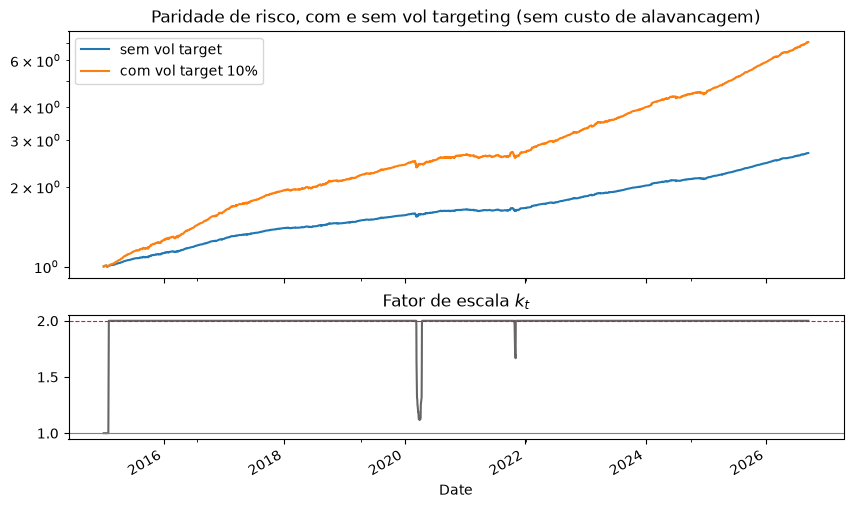

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
pd.DataFrame({"sem vol target": (1 + p).cumprod(),
              "com vol target 10%": (1 + p_vt_free).cumprod()}).plot(ax=ax1, logy=True,
              title="Paridade de risco, com e sem vol targeting (sem custo de alavancagem)")
k.plot(ax=ax2, color="0.4", title="Fator de escala $k_t$")
ax2.axhline(2.0, color="crimson", ls="--", lw=0.8)
ax2.axhline(1.0, color="gray", lw=0.8);

In [22]:
# a conta honesta: a parte alavancada é dinheiro emprestado e paga juros
# k > 1 toma emprestado a CDI+spread; k < 1 aplica a sobra no CDI
def vol_target_returns(ret, cdi, k, spread=0.0):
    emprestado = (k - 1).clip(lower=0)
    caixa = (1 - k).clip(lower=0)
    return k * ret - emprestado * (cdi + spread / 252) + caixa * cdi

variantes = {
    "sem vol target":            p,
    "vt, alavancagem de graça":  p_vt_free,
    "vt, funding a CDI":         vol_target_returns(p, cdi, k),
    "vt, funding a CDI + 1%":    vol_target_returns(p, cdi, k, spread=0.01),
}
pd.DataFrame({nome: metrics.summary(s, cdi) for nome, s in variantes.items()}).T.round(3)

,ret_anual,vol_anual,sharpe,max_dd
sem vol target,0.089,0.018,-0.554,-0.028
"vt, alavancagem de graça",0.184,0.034,2.189,-0.055
"vt, funding a CDI",0.077,0.034,-0.597,-0.057
"vt, funding a CDI + 1%",0.067,0.034,-0.889,-0.065


**O vol targeting não atingiu o alvo, e não tinha como.** A carteira de paridade de risco tem vol de 1,8% e o alvo é 10%: seriam necessárias **5,6 vezes** de alavancagem, e o teto é 2. O resultado é que `k` fica **grudado em 2,0 em 98,2% dos pregões** e nunca cai abaixo de 1. A vol sobe de 1,8% para 3,4% — exatamente o dobro, e nada perto dos 10%.

Isso quer dizer que aqui não há vol targeting nenhum: **é uma posição alavancada em 2× de ponta a ponta**, com o nome errado. O gráfico de `k_t` mostra uma reta na linha vermelha, não uma resposta à vol do mercado. Para o mecanismo de fato operar, o alvo teria que ser compatível com a carteira (algo como 3%), ou o teto teria que ser muito maior — e aí o problema passa a ser outro.

**A nota que muda a conclusão: alavancagem não é de graça.** A fórmula da célula ingênua adiciona CDI sobre a sobra quando `k < 1`, mas não cobra nada quando `k > 1` — ou seja, toma emprestado a juro zero. Como `k` é 2 praticamente sempre, ela **dobra o retorno sem pagar por metade dele**, e o Sharpe pula de −0,55 para **+2,19**. Esse é o número mais bonito do notebook inteiro e é integralmente artificial.

Financiando a parte alavancada a CDI — o mínimo concebível, e otimista: uma pessoa física paga bem mais que isso —, o Sharpe volta para **−0,60**. Com CDI + 1% ao ano, **−0,89**. Alavancar uma carteira que rende menos que o custo do dinheiro só multiplica o prejuízo, e é por isso que a linha honesta fica **abaixo** da carteira sem alavancagem nenhuma. A série que vai para o arquivo final na seção 10 é a com funding a CDI.

## 8. Fatores NEFIN — o retorno é meu ou é do mercado?

Sharpe positivo pode ser habilidade ou pode ser exposição a um prêmio de risco que qualquer ETF entrega mais barato. A regressão separa as duas coisas:

$$r_t - \text{cdi}_t \;=\; \alpha \;+\; \beta_{\text{MKT}}\,\text{MKT}_t + \beta_{\text{SMB}}\,\text{SMB}_t + \beta_{\text{HML}}\,\text{HML}_t + \beta_{\text{WML}}\,\text{WML}_t \;+\; \varepsilon_t$$

Os quatro fatores são os do NEFIN/USP para o mercado brasileiro: mercado, tamanho, valor e momento. O que interessa é o **alpha** — o que sobra depois de descontar tudo o que é fator — e o **t** dele.

In [23]:
import statsmodels.api as sm

def regressao_fatores(ret, cdi, F):
    y = (ret - cdi).dropna()
    X = sm.add_constant(F.loc[y.index].dropna())
    y = y.loc[X.index]
    m = sm.OLS(y, X).fit()
    return pd.Series({"alpha_anual": m.params["const"] * 252, "t_alpha": m.tvalues["const"],
                      **{f"beta_{c}": m.params[c] for c in F.columns}, "R2": m.rsquared})

linhas = {c: regressao_fatores(R[c], cdi, F) for c in R.columns}
linhas.update({f"[{n}]": regressao_fatores(P[n], cdi, F) for n in P.columns})
pd.DataFrame(linhas).T.round(3)

,alpha_anual,t_alpha,beta_MKT,beta_SMB,beta_HML,beta_WML,R2
momentum,-0.013,-0.277,0.942,0.044,0.120,0.347,0.657
reversao,-0.311,-3.071,0.224,0.061,-0.092,0.310,0.036
pares,-0.057,-2.191,-0.076,0.005,0.017,0.038,0.042
carry,-0.001,-0.477,0.002,-0.001,-0.001,-0.000,0.003
[pesos_iguais],-0.096,-3.261,0.273,0.027,0.011,0.174,0.304
[risk_parity],-0.015,-3.144,0.031,0.003,0.003,0.023,0.182
[max_sharpe],-0.017,-0.867,0.363,0.018,0.051,0.146,0.616


**Nenhum alpha positivo em lugar nenhum da tabela.** Estratégia por estratégia:

- **Momentum — alpha −1,3% ao ano (t = −0,28), R² = 0,66.** É o achado mais importante da seção. A única estratégia que ganhou do CDI tem **β<sub>MKT</sub> = 0,94** e **β<sub>WML</sub> = 0,35**: comprar as ações que mais subiram é estar quase inteiramente comprado no mercado, com um tempero de momento. Dois terços da variação dela é explicada por fatores, e o que sobra é zero. O Sharpe de 0,35 da seção 1 não é habilidade — é beta de mercado, que se compra num ETF sem backtest nenhum.
- **Reversão — alpha −31,1% ao ano (t = −3,07).** Significativamente negativo, e o R² de 0,04 mostra que não dá nem para culpar os fatores: o prejuízo é próprio.
- **Pares — alpha −5,7% ao ano (t = −2,19).** Neutra a fatores, como um long-short deve ser (β<sub>MKT</sub> = −0,08, R² = 0,04). Neutra e perdedora.
- **Carry — alpha −0,1% ao ano (t = −0,48), R² = 0,003.** Zero em tudo, como esperado de uma série que é quase caixa. É o único cujo alpha não é estatisticamente distinguível de zero por mérito, e não por falta de dado.

Nas combinações o quadro se repete: `max_sharpe` tem alpha de −1,7% (t = −0,87) com β<sub>MKT</sub> = 0,36 e R² de 0,62 — é uma versão desalavancada do momentum, portanto do mercado. Os alphas de pesos iguais (−9,6%, t = −3,26) e paridade de risco (−1,5%, t = −3,14) são negativos com significância.

**Juntando com a seção 6:** o único resultado positivo do notebook (Sharpe 0,25 do `max_sharpe`) vem de uma carteira cujo alpha é nulo e cujo beta de mercado é 0,36. Não há nada aqui que um ETF do Ibovespa e um CDB não façam.

## 9. Pesos rolantes — a tabela honesta

A armadilha da seção 6, corrigida: em vez de calcular os pesos com a amostra inteira, treino em **3 anos** e aplico no ano seguinte, andando um ano de cada vez. Cada retorno abaixo foi gerado por pesos que nunca viram aquele ano.

Como isso só começa em 2018, a comparação justa precisa de três colunas: o número da seção 6, o mesmo número recortado no período do rolante (para separar o efeito de período), e o rolante de verdade.

In [24]:
# treina em `anos_treino` anos, aplica no ano seguinte, anda um ano
def alocacao_rolante(R, cdi, metodo, anos_treino=3):
    anos = sorted(set(R.index.year))
    retornos, pesos = [], {}
    for i in range(anos_treino, len(anos)):
        treino = R[R.index.year.isin(anos[i - anos_treino:i])]
        teste  = R[R.index.year == anos[i]]
        w = (metodo(treino, cdi.reindex(treino.index), w_max=0.4)
             if metodo is portfolio.max_sharpe else metodo(treino))
        pesos[anos[i]] = w
        retornos.append(portfolio.combine(teste, w))
    return pd.concat(retornos), pd.DataFrame(pesos).T

metodos = {"pesos_iguais": portfolio.equal_weight,
           "risk_parity":  portfolio.risk_parity,
           "max_sharpe":   portfolio.max_sharpe}

P_rol = {}; W_rol = {}
for nome, m in metodos.items():
    P_rol[nome], W_rol[nome] = alocacao_rolante(R, cdi, m)
P_rol = pd.DataFrame(P_rol)
cdi_rol = cdi.reindex(P_rol.index)

print("período do rolante:", P_rol.index.min().date(), "->", P_rol.index.max().date(), f"| {len(P_rol)} pregões")
pd.DataFrame({c: metrics.summary(P_rol[c], cdi_rol) for c in P_rol.columns}).T.round(3)

período do rolante: 2018-01-02 -> 2026-09-14 | 2163 pregões


,ret_anual,vol_anual,sharpe,max_dd
pesos_iguais,0.018,0.112,-0.572,-0.267
risk_parity,0.078,0.017,-0.735,-0.024
max_sharpe,0.095,0.114,0.078,-0.249


In [25]:
honesta = pd.DataFrame({
    "pesos da amostra toda (2015-26)": {c: metrics.sharpe(P[c], cdi) for c in P.columns},
    "pesos da amostra toda (2018-26)": {c: metrics.sharpe(P[c].reindex(P_rol.index), cdi_rol) for c in P.columns},
    "pesos rolantes (2018-26)":        {c: metrics.sharpe(P_rol[c], cdi_rol) for c in P_rol.columns},
})
honesta.loc["melhor isolada (momentum)"] = [metrics.sharpe(R["momentum"], cdi),
                                            metrics.sharpe(R["momentum"].reindex(P_rol.index), cdi_rol),
                                            metrics.sharpe(R["momentum"].reindex(P_rol.index), cdi_rol)]
honesta.round(3)

,pesos da amostra toda (2015-26),pesos da amostra toda (2018-26),pesos rolantes (2018-26)
pesos_iguais,-0.497,-0.572,-0.572
risk_parity,-0.554,-0.667,-0.735
max_sharpe,0.248,0.135,0.078
melhor isolada (momentum),0.354,0.223,0.223


In [26]:
W_rol["max_sharpe"].round(2)      # os pesos que o otimizador pediu, ano a ano

,momentum,reversao,pares,carry
2018,0.40,0.0,0.20,0.4
2019,0.40,0.0,0.20,0.4
2020,0.40,0.0,0.20,0.4
2021,0.40,0.0,0.20,0.4
2022,0.22,0.0,0.38,0.4
2023,0.40,0.0,0.40,0.2
2024,0.40,0.0,0.20,0.4
2025,0.40,0.4,0.00,0.2
2026,0.40,0.4,0.00,0.2


**A tabela honesta, em Sharpe:**

| | pesos da amostra toda (2015-26) | mesmo, recortado em 2018-26 | **pesos rolantes (2018-26)** |
|---|---|---|---|
| pesos iguais | −0,50 | −0,57 | **−0,57** |
| paridade de risco | −0,55 | −0,67 | **−0,74** |
| máximo Sharpe | **+0,25** | +0,14 | **+0,08** |
| melhor isolada (momentum) | +0,35 | +0,22 | +0,22 |

O `max_sharpe` perde **dois terços** do resultado quando para de espiar: de 0,25 para 0,08. E a queda vem de duas fontes distintas, que a coluna do meio separa — metade é só o período (0,25 → 0,14, recorte igual, pesos iguais aos da seção 6) e a outra metade é o gabarito (0,14 → 0,08). Pesos iguais não muda nada entre as duas últimas colunas, como tem que ser: ele não usa dado nenhum, então não existe versão dele "fora da amostra".

**Os pesos rolantes explicam o resto.** O otimizador passa oito dos nove anos com momentum e carry no teto e a reversão zerada, e aí, em **2025**, muda de ideia: coloca **40% na reversão** e zera o par. Nada aconteceu em 2025 que justifique — é o mesmo efeito da seção 5, uma janela de treino diferente atravessando o ponto em que o encolhimento faz a pior série parecer aceitável. Os pesos da paridade de risco, em compensação, quase não se mexem (carry entre 82,7% e 88,3% em todos os anos): vol é estável, média não é.

**O número em que eu acredito desta fase é +0,08** — e ele continua abaixo do momentum sozinho no mesmo período (+0,22), que por sua vez tem alpha zero pela seção 8.

## 10. Registro

In [27]:
k_final = portfolio.vol_target_scale(P["risk_parity"], target=0.10, window=21, max_leverage=2.0)
p_final = vol_target_returns(P["risk_parity"], cdi, k_final)      # com funding a CDI

saida = pd.DataFrame({"portfolio": p_final, "cdi": cdi})
saida.to_parquet(DATA / "processed" / "portfolio_final.parquet")

conferindo = pd.read_parquet(DATA / "processed" / "portfolio_final.parquet")
print("salvo:", conferindo.shape, list(conferindo.columns), "| igual ao da memória:", conferindo.equals(saida))
pd.DataFrame({c: metrics.summary(saida[c], cdi) for c in saida.columns}).T.round(3)

salvo: (2912, 2) ['portfolio', 'cdi'] | igual ao da memória: True


,ret_anual,vol_anual,sharpe,max_dd
portfolio,0.077,0.034,-0.597,-0.057
cdi,0.100,0.002,NaN,0.000


**Os parâmetros, todos escolhidos por mim e nenhum calibrado:**

| parâmetro | valor | onde entra | como foi escolhido |
|---|---|---|---|
| `w_max` | **0,40** | `portfolio.max_sharpe` | arbitrário. A seção 5 mostra que ele **é** a alocação: 1,0 dá 100% momentum, 0,25 dá pesos iguais |
| `shrink` | **0,50** | `portfolio.max_sharpe` | arbitrário. Entre 0 e 0,5 não muda nada; em 0,75 os pesos viram outra carteira |
| vol alvo | **10% ao ano** | `portfolio.vol_target_scale` | inalcançável para a carteira usada (vol de 1,8%, exigiria 5,6× de alavancagem) |
| `max_leverage` | **2,0** | `portfolio.vol_target_scale` | é o parâmetro que de fato manda: `k` fica nele em 98,2% dos dias |
| janela de vol | **21 dias** | `portfolio.vol_target_scale` | um mês, por convenção; nunca testei outra |
| janela de treino | **3 anos**, teste de 1 | `alocacao_rolante` (seção 9) | mesma convenção da Fase 5 |
| custo de funding | **CDI** | `vol_target_returns` | o mínimo concebível; pessoa física paga mais |
| dias de estresse | **5% piores do MKT** | seção 2 | 143 pregões; com 10% as correlações caem um pouco, a conclusão não muda |

**O arquivo:** `data/processed/portfolio_final.parquet`, com a carteira de paridade de risco alavancada a 2× e **com o custo do empréstimo cobrado a CDI** — não a versão da célula ingênua, que rendia Sharpe +2,19 por tomar dinheiro emprestado de graça.

### O que ainda é otimista

Em ordem de gravidade:

1. **A melhor combinação continua sendo a que viu o gabarito.** A seção 9 corrige isso e sobra Sharpe **+0,08** — positivo, mas indistinguível de zero em 2.163 pregões. E mesmo esse número herda todas as escolhas da Fase 5; o único ponto em que o notebook inteiro fica acima do CDI depende de `w_max = 0,4`.
2. **Nada aqui tem alpha.** A seção 8 mostra que o resultado positivo é β<sub>MKT</sub> = 0,36 com alpha nulo. Um ETF de Ibovespa mais CDB entrega o mesmo perfil sem custo de execução, sem risco de modelo e sem seis fases de trabalho.
3. **A alavancagem é hipotética.** Vol targeting a 2× supõe que dá para tomar emprestado a CDI, continuamente, sem chamada de margem e sem limite de crédito. Nenhuma das três coisas vale para o investidor que este projeto simula; a variante "CDI + 1%" da seção 7 provavelmente ainda é otimista.
4. **Rebalanceamento diário sem custo.** `portfolio.combine` assume pesos fixos com rebalanceamento diário implícito, e o vol targeting muda o tamanho da posição todo dia — **nenhuma das duas coisas paga corretagem**. Os 10 bps da Fase 5 cobrem o giro *dentro* de cada estratégia, não o giro *entre* elas. A coluna `turnover` da tabela da seção 1 seria o lugar de medir isso, e ela não existe nesta versão.
5. **Matriz de covariância fixa em regime que não é fixo.** Paridade de risco e Markowitz usam uma covariância de amostra única, e a seção 2 mostra a correlação momentum × reversão indo de +0,15 para +0,60 no estresse e passeando entre −0,2 e +0,5 na janela móvel. Os pesos são calculados para um mercado médio que nunca acontece.
6. **Tudo herda o viés de sobrevivência da Fase 5.** O universo são 23 ações escolhidas hoje entre as que continuam grandes e líquidas. O erro tem sempre o mesmo sinal, não sai com mais dados e contamina principalmente o momentum — que é a estratégia que carrega todo o resultado positivo daqui.

**A conclusão da fase, em uma linha:** combinar quatro estratégias pouco correlacionadas reduziu bastante o risco (vol de 27% para 11%, drawdown de −54% para −25%) e não produziu retorno acima do CDI que sobreviva a escolher os pesos sem olhar o resultado.